In [1]:
import sys
sys.path.append('..')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import datasets

from tqdm.notebook import tqdm
from torchaudio import functional as F
from torchaudio.transforms import MelSpectrogram, MFCC
from transformers import AutoModel

from utils import show_audios, draw_spec
from src.training_and_inference.datasets import SpeechTranscriptDataset
from src.training_and_inference.training_utils import load_vn_speech_transcript_datasets

In [ ]:
clean_data = load_vn_speech_transcript_datasets(
    16000,
    .8,
    torch.linspace(0, 20, 21),
    return_data_loader=True,
    mos_sig_thres=3.5,
    seed=4
)

data = []
_SOURCES = [
    ("fosd", "doof-ferb/fpt_fosd"),
    ("vlsp", "doof-ferb/vlsp2020_vinai_100h")
]
dfs = []

for name, path in _SOURCES:
    df = pd.read_csv(f"../data/dnsmos/{name}.csv", index_col=0)
    mask = (df['mos_bak'] >= 3) & (df['mos_bak'] < 4)
    # mask = (df['mos_bak'] >= 2) & (df['mos_bak'] < 3)
    df = df[mask].sample(frac=0.1, random_state=4)

    data.append(datasets.load_dataset(path, split='train').select(
        df.loc[mask].index.to_list()
    ))
    dfs.append(df)
    print(f"Kept {df.shape[0]} rows from {name}")

unseen = SpeechTranscriptDataset(
    dataset=datasets.concatenate_datasets(data),
    preprocessor=lambda wf, sr: F.resample(wf, sr, 16000)
)

In [6]:
def get_features(wfs, *, tol=1e-8):
    res = {
        'num_samples': [],
        'avg_power': [],
        'peak_power': [],
        'avg_power_dB': [],
        'peak_power_dB': []
    }
    for wf in wfs:
        power = wf ** 2

        res['num_samples'].append(wf.shape[-1])
        res['avg_power'].append(power.mean().item())
        res['peak_power'].append(power.max().item())
        res['avg_power_dB'].append(10 * torch.log10(power.mean() + tol).item())
        res['peak_power_dB'].append(10 * torch.log10(power.max() + tol).item())

    return res

mel_kwargs = {"n_mels": 80, "n_fft": 2048, "hop_length": 512}
mel_spec_fn = MelSpectrogram(**mel_kwargs)
mfcc_spec_fn = MFCC(n_mfcc=13, melkwargs=mel_kwargs)

def get_spectral_stat(wf, *, tol=1e-8):
    spec = mel_spec_fn(wf)
    log_spec=  10 * torch.log10(spec + tol)

    mu, std = log_spec.mean(dim=-1), log_spec.std(dim=-1)
    delta_std = log_spec.diff(dim=-1).std(dim=-1)

    return torch.stack([mu, std, delta_std], dim=-1), mfcc_spec_fn(wf).mean(dim=-1)

In [ ]:
meta = {
    split: pd.DataFrame(get_features(
        tqdm(clean_data[split]['speech_dataset']['audio'])
    ))
    for split in ['train', 'test']
}
meta['unseen'] = pd.DataFrame(get_features(unseen['audio']))
meta = pd.concat(meta, axis=0)

meta['dur_sec'] = meta['num_samples'] / 16000
meta['PAPR'] = meta['peak_power'] / (meta['avg_power'] + 1e-8)
meta['PAPR_dB'] = 10 * np.log10(meta['PAPR'] + 1e-8)

In [ ]:
augmented_meta = {'train': [], 'test': []}

for _ in range(2):
    for _, noisy, _, lens, _ in tqdm(clean_data['train']['loader']):
        augmented_meta['train'].append(pd.DataFrame(get_features(
            wf[..., :length] for wf, length in zip(noisy, lens)
        )))

for _, noisy, _, lens, _ in tqdm(clean_data['test']['loader']):
    augmented_meta['test'].append(pd.DataFrame(get_features(
        wf[..., :length] for wf, length in zip(noisy, lens)
    )))

augmented_meta['train'] = pd.concat(augmented_meta['train'])
augmented_meta['test'] = pd.concat(augmented_meta['test'])

augmented_meta = pd.concat(augmented_meta, axis=0)

augmented_meta['dur_sec'] = augmented_meta['num_samples'] / 16000
augmented_meta['PAPR'] = augmented_meta['peak_power'] / augmented_meta['avg_power']
augmented_meta['PAPR_dB'] = 10 * np.log10(augmented_meta['PAPR'])

  0%|          | 0/93 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

In [81]:
spectral_feats = {
    "train": {"mels": [], "mfcc": []},
    "test": {"mels": [], "mfcc": []},
    "unseen": {"mels": [], "mfcc": []}
}
for split, df in spectral_feats.items():
    if split == 'unseen':
        data = unseen['audio']
    else:
        data = clean_data[split]['speech_dataset']['audio']

    for wf in tqdm(data):
        mels, mfcc = get_spectral_stat(wf)
        df['mels'].append(mels)
        df['mfcc'].append(mfcc)
    df['mels'] = torch.stack(df['mels'])
    df['mfcc'] = torch.stack(df['mfcc'])

  0%|          | 0/2952 [00:00<?, ?it/s]

  0%|          | 0/738 [00:00<?, ?it/s]

  0%|          | 0/5601 [00:00<?, ?it/s]

# Vis

In [28]:
import seaborn as sns

from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [29]:
def plot_split_hist(
    splits: dict,
    title,
    xlabel,
    ax,
    log_scale=True,
    *,
    bins=35,
    height_offsets=.17,
    fontsize=12,
):
    bins = np.histogram_bin_edges(splits['All'][0], bins=bins)

    for split, (samples, color, hist_label) in splits.items():
        mu, std = samples.mean(), samples.std()

        ax.hist(
            samples,
            density=True,
            bins=bins,
            color=color,
            label=hist_label,
            alpha=.25 if split == 'All' else .6,
            edgecolor='black' if split == 'All' else None
        )

        ax.axvline(x=mu, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
        ax.errorbar(
            x=mu,
            y=height_offsets,
            xerr=std,
            fmt='o',
            color=color,
            elinewidth=2.5,
            capsize=6,
            label=rf'{split}: ${mu:.2f} \pm {std:.2f}$'
        )

    ax.set_xlabel(xlabel, fontsize=fontsize)
    if log_scale:
        ax.set_yscale('log')
        ax.set_ylabel('Log Density', fontsize=fontsize)
    else:
        ax.set_ylabel('Density', fontsize=fontsize)

    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=True)
    ax.grid(axis='y', alpha=0.5)
    return ax

def plot_spectral_stats(
    spec_mat,
    title,
    ax,
    *,
    ylabel="Mel Band",
    cmap='viridis'
):
    img = ax.imshow(spec_mat, aspect='auto', origin='lower', cmap=cmap)
    ax.set_xlabel("Samples")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    return ax, img

def plot_reduced_dims(
    spec_mat,
    labels,
    ax,
    return_reducer = False,
    *,
    tsne: bool = False,
    palette=['#1f77b4', '#ff7f0e'],
    tsne_kwargs=None,
    umap_kwargs=None,
    random_state=4
):
    reducer = (
        TSNE(random_state=random_state, **(tsne_kwargs or {}))
        if tsne else UMAP(random_state=random_state, **(umap_kwargs or {}))
    )
    scaler = StandardScaler()
    res = reducer.fit_transform(scaler.fit_transform(spec_mat))

    sns.scatterplot(
        x=res[:, 0],
        y=res[:, 1],
        hue=labels,
        palette=palette,
        alpha=0.4,
        edgecolor='none',
        s=15,
        ax=ax
    )

    ax.set_title(("t-SNE" if tsne else "UMAP") + " Projections")
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')
    ax.grid(True, alpha=0.3)

    if return_reducer:
        return ax, res, (scaler, reducer)
    return ax, res

## Distribution

Distribution of filtered training data

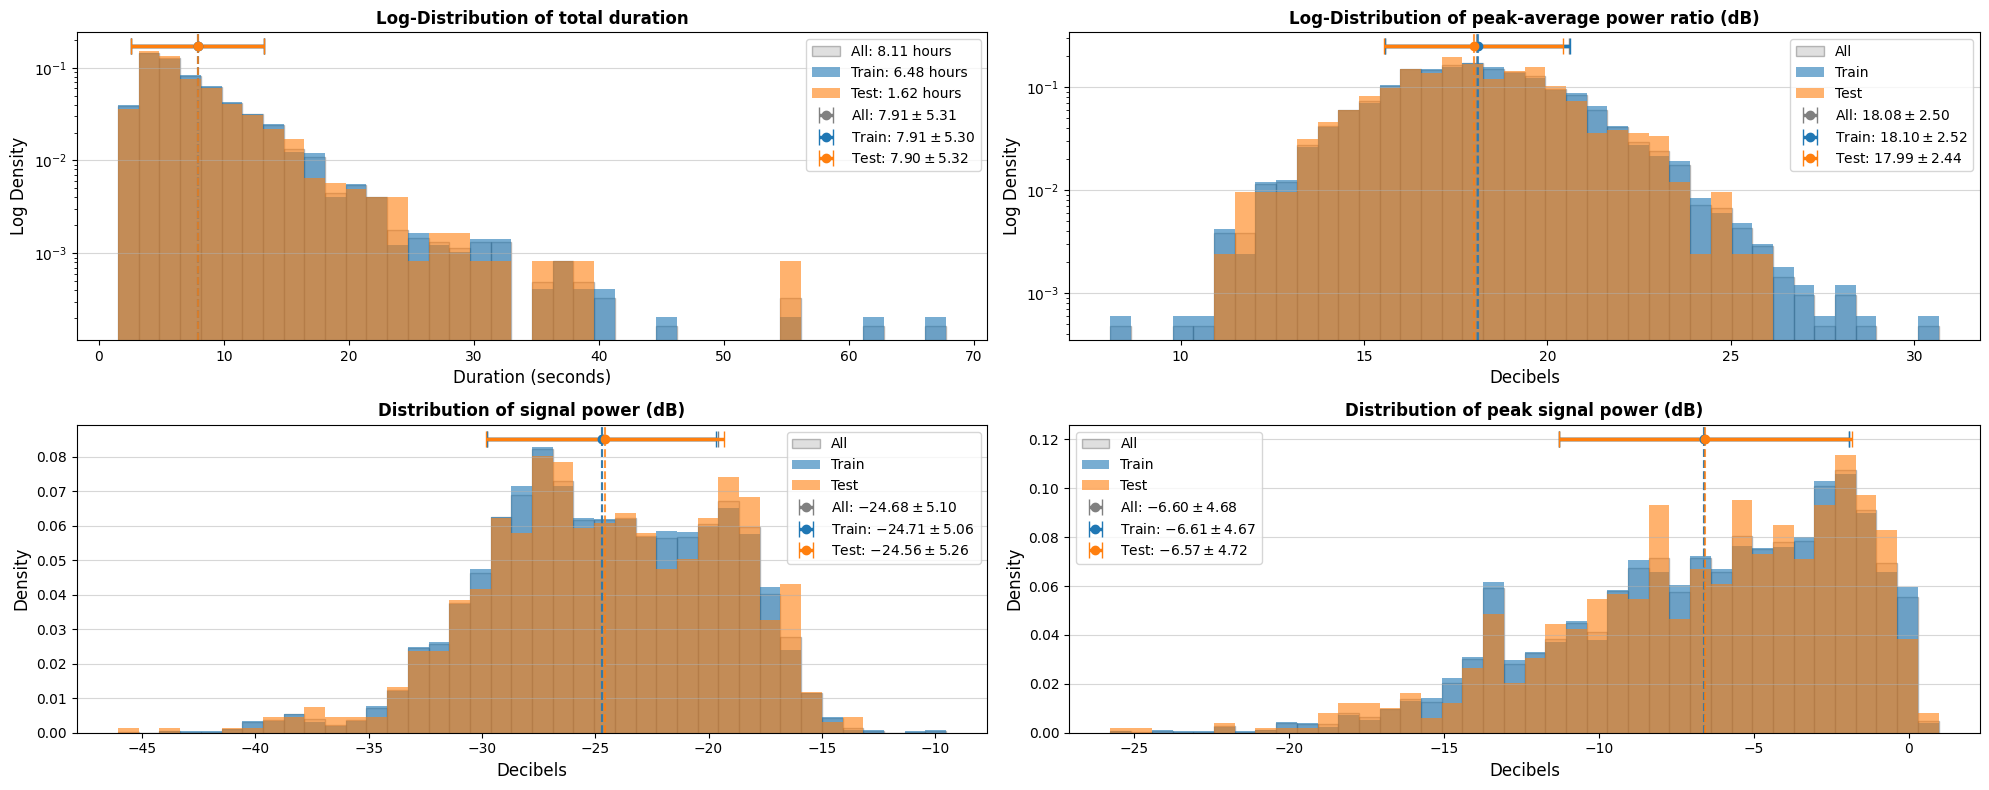

In [82]:
bins = 40
df = meta[meta.index.get_level_values(0) != 'unseen']
stats = {
    "duration": {
        'All': (df['dur_sec'], 'grey', f'All: {df['dur_sec'].sum() / 3600:.2f} hours'),
        'Train': (
            df.loc['train', 'dur_sec'],
            '#1f77b4',
            f"Train: {df.loc['train', 'dur_sec'].sum() / 3600:.2f} hours",
        ),
        'Test': (
            df.loc['test', 'dur_sec'],
            '#ff7f0e',
            f"Test: {df.loc['test', 'dur_sec'].sum() / 3600:.2f} hours",
        )
    },
    "mean_power": {
        'All': (df['avg_power_dB'], 'grey', 'All'),
        'Train': (df.loc['train', 'avg_power_dB'], '#1f77b4', f"Train"),
        'Test': (df.loc['test', 'avg_power_dB'], '#ff7f0e', f"Test")
    },
    "peak_power": {
        'All': (df['peak_power_dB'], 'grey', 'All'),
        'Train': (df.loc['train', 'peak_power_dB'], '#1f77b4', f"Train"),
        'Test': (df.loc['test', 'peak_power_dB'], '#ff7f0e', f"Test")
    },
    "papr": {
        'All': (df['PAPR_dB'], 'grey', 'All'),
        'Train': (df.loc['train', 'PAPR_dB'], '#1f77b4', f"Train"),
        'Test': (df.loc['test', 'PAPR_dB'], '#ff7f0e', f"Test")
    }
}

fig = plt.figure(figsize=(20, 8))
axes = fig.subplots(2, 2)

plot_split_hist(
    stats['duration'],
    'Log-Distribution of total duration',
    'Duration (seconds)',
    axes[0, 0],
    bins=bins
)
plot_split_hist(
    stats['papr'],
    'Log-Distribution of peak-average power ratio (dB)',
    'Decibels',
    axes[0, 1],
    height_offsets=.25,
    bins=bins
)
plot_split_hist(
    stats['mean_power'],
    'Distribution of signal power (dB)',
    'Decibels',
    axes[1, 0],
    height_offsets=.085,
    log_scale=False,
    bins=bins
)
plot_split_hist(
    stats['peak_power'],
    'Distribution of peak signal power (dB)',
    'Decibels',
    axes[1, 1],
    height_offsets=.12,
    log_scale=False,
    bins=bins
)

plt.tight_layout()
plt.show()

Distribution of Augmented Samples with SNR and RIR noises

/tmp/ipykernel_54272/3766573243.py:5: PerformanceWarning: indexing past lexsort depth may impact performance.
  augmented_meta.loc['train', 'dur_sec'],
/tmp/ipykernel_54272/3766573243.py:7: PerformanceWarning: indexing past lexsort depth may impact performance.
  f"Train: {augmented_meta.loc['train', 'dur_sec'].sum() / 3600:.2f} hours",
/tmp/ipykernel_54272/3766573243.py:10: PerformanceWarning: indexing past lexsort depth may impact performance.
  augmented_meta.loc['test', 'dur_sec'],
/tmp/ipykernel_54272/3766573243.py:12: PerformanceWarning: indexing past lexsort depth may impact performance.
  f"Test: {augmented_meta.loc['test', 'dur_sec'].sum() / 3600:.2f} hours",
/tmp/ipykernel_54272/3766573243.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  'All': (augmented_meta.loc['train', 'avg_power_dB'], '#1f77b4', f"Train"),
/tmp/ipykernel_54272/3766573243.py:17: PerformanceWarning: indexing past lexsort depth may impact performance.
  'Test': (augmented_met

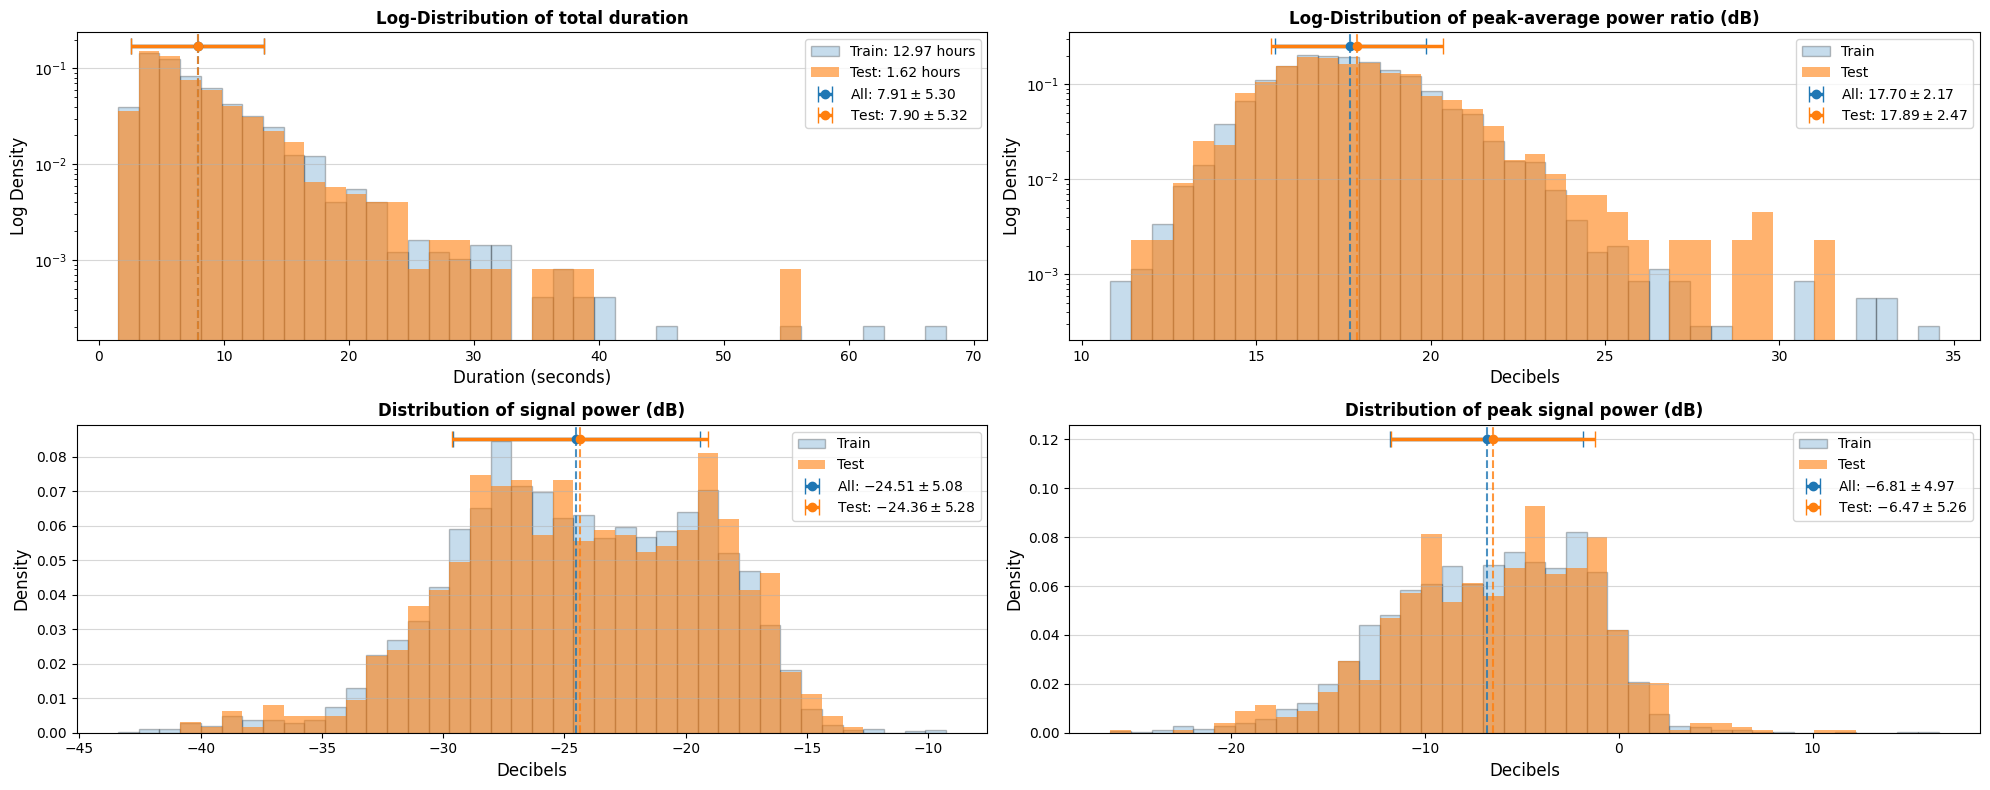

In [83]:
bins = 40
stats = {
    "duration": {
        'All': (
            augmented_meta.loc['train', 'dur_sec'],
            '#1f77b4',
            f"Train: {augmented_meta.loc['train', 'dur_sec'].sum() / 3600:.2f} hours",
        ),
        'Test': (
            augmented_meta.loc['test', 'dur_sec'],
            '#ff7f0e',
            f"Test: {augmented_meta.loc['test', 'dur_sec'].sum() / 3600:.2f} hours",
        )
    },
    "mean_power": {
        'All': (augmented_meta.loc['train', 'avg_power_dB'], '#1f77b4', f"Train"),
        'Test': (augmented_meta.loc['test', 'avg_power_dB'], '#ff7f0e', f"Test")
    },
    "peak_power": {
        'All': (augmented_meta.loc['train', 'peak_power_dB'], '#1f77b4', f"Train"),
        'Test': (augmented_meta.loc['test', 'peak_power_dB'], '#ff7f0e', f"Test")
    },
    "papr": {
        'All': (augmented_meta.loc['train', 'PAPR_dB'], '#1f77b4', f"Train"),
        'Test': (augmented_meta.loc['test', 'PAPR_dB'], '#ff7f0e', f"Test")
    }
}

fig = plt.figure(figsize=(20, 8))
axes = fig.subplots(2, 2)

plot_split_hist(
    stats['duration'],
    'Log-Distribution of total duration',
    'Duration (seconds)',
    axes[0, 0],
    bins=bins
)
plot_split_hist(
    stats['papr'],
    'Log-Distribution of peak-average power ratio (dB)',
    'Decibels',
    axes[0, 1],
    height_offsets=.25,
    bins=bins
)
plot_split_hist(
    stats['mean_power'],
    'Distribution of signal power (dB)',
    'Decibels',
    axes[1, 0],
    height_offsets=.085,
    log_scale=False,
    bins=bins
)
plot_split_hist(
    stats['peak_power'],
    'Distribution of peak signal power (dB)',
    'Decibels',
    axes[1, 1],
    height_offsets=.12,
    log_scale=False,
    bins=bins
)

plt.tight_layout()
plt.show()

Distribution of noisy signals from original dataset

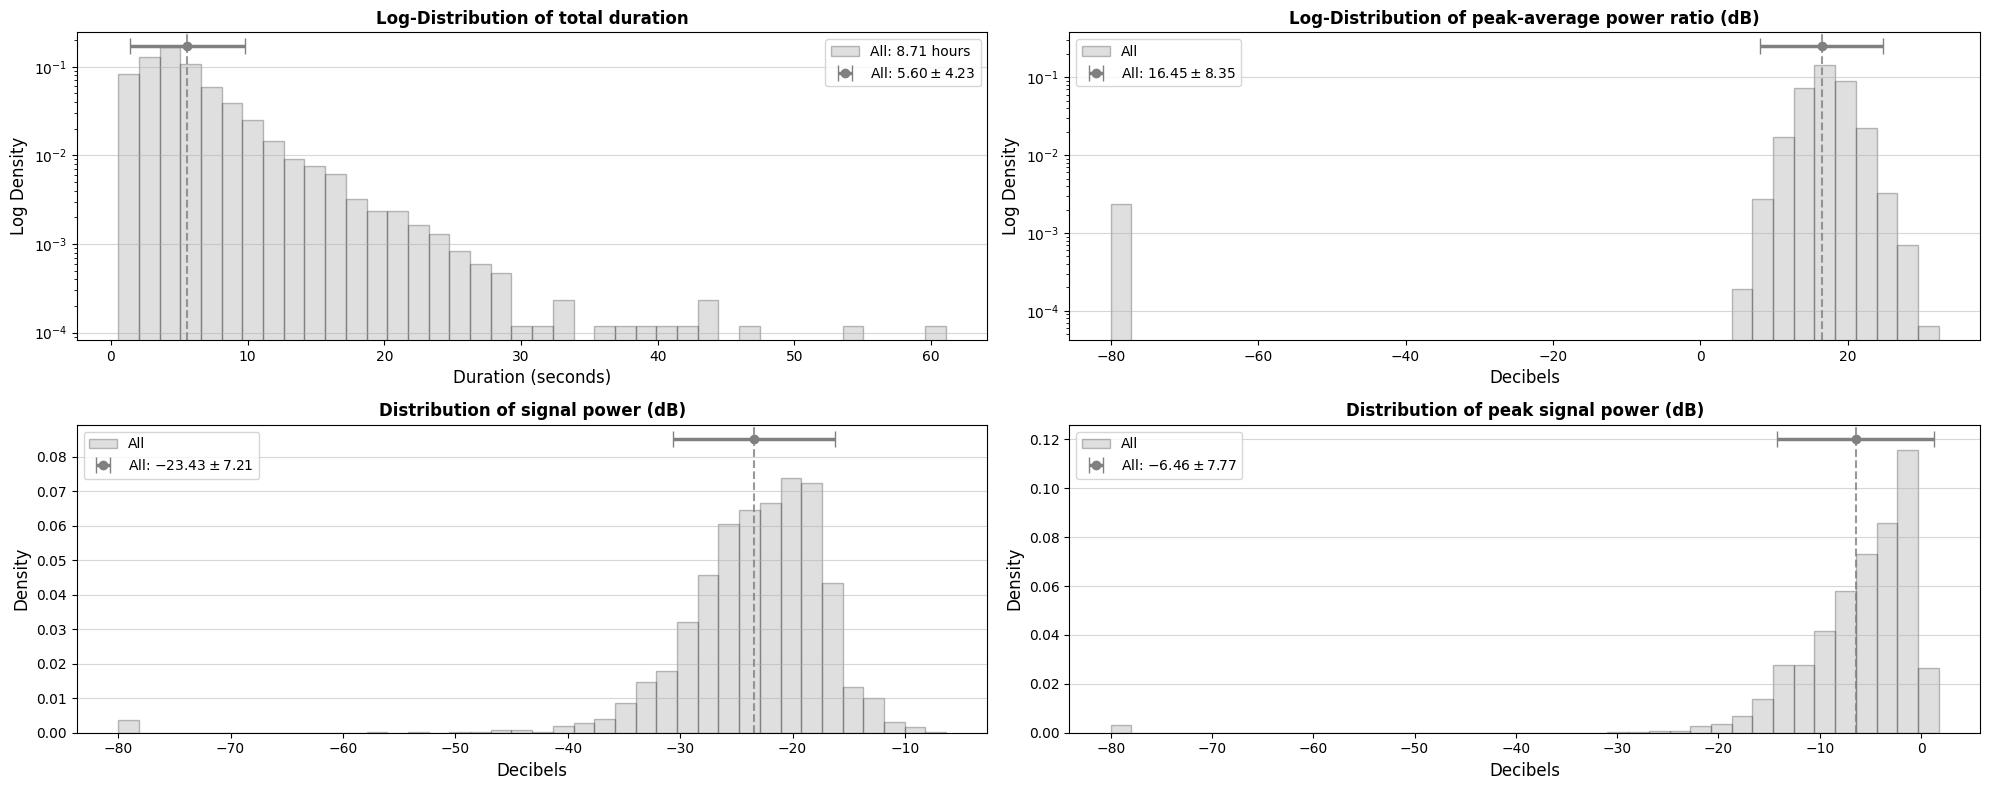

In [84]:
bins = 40
df = meta[meta.index.get_level_values(0) == 'unseen']
stats = {
    "duration": {
        'All': (df['dur_sec'], 'grey', f'All: {df['dur_sec'].sum() / 3600:.2f} hours'),
    },
    "mean_power": {
        'All': (df['avg_power_dB'], 'grey', 'All'),
    },
    "peak_power": {
        'All': (df['peak_power_dB'], 'grey', 'All'),
    },
    "papr": {
        'All': (df['PAPR_dB'], 'grey', 'All'),
    }
}

fig = plt.figure(figsize=(20, 8))
axes = fig.subplots(2, 2)

plot_split_hist(
    stats['duration'],
    'Log-Distribution of total duration',
    'Duration (seconds)',
    axes[0, 0],
    bins=bins
)
plot_split_hist(
    stats['papr'],
    'Log-Distribution of peak-average power ratio (dB)',
    'Decibels',
    axes[0, 1],
    height_offsets=.25,
    bins=bins
)
plot_split_hist(
    stats['mean_power'],
    'Distribution of signal power (dB)',
    'Decibels',
    axes[1, 0],
    height_offsets=.085,
    log_scale=False,
    bins=bins
)
plot_split_hist(
    stats['peak_power'],
    'Distribution of peak signal power (dB)',
    'Decibels',
    axes[1, 1],
    height_offsets=.12,
    log_scale=False,
    bins=bins
)

plt.tight_layout()
plt.show()

## Spectral Variance

/home/cactr/Projects/denoise-vdt/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


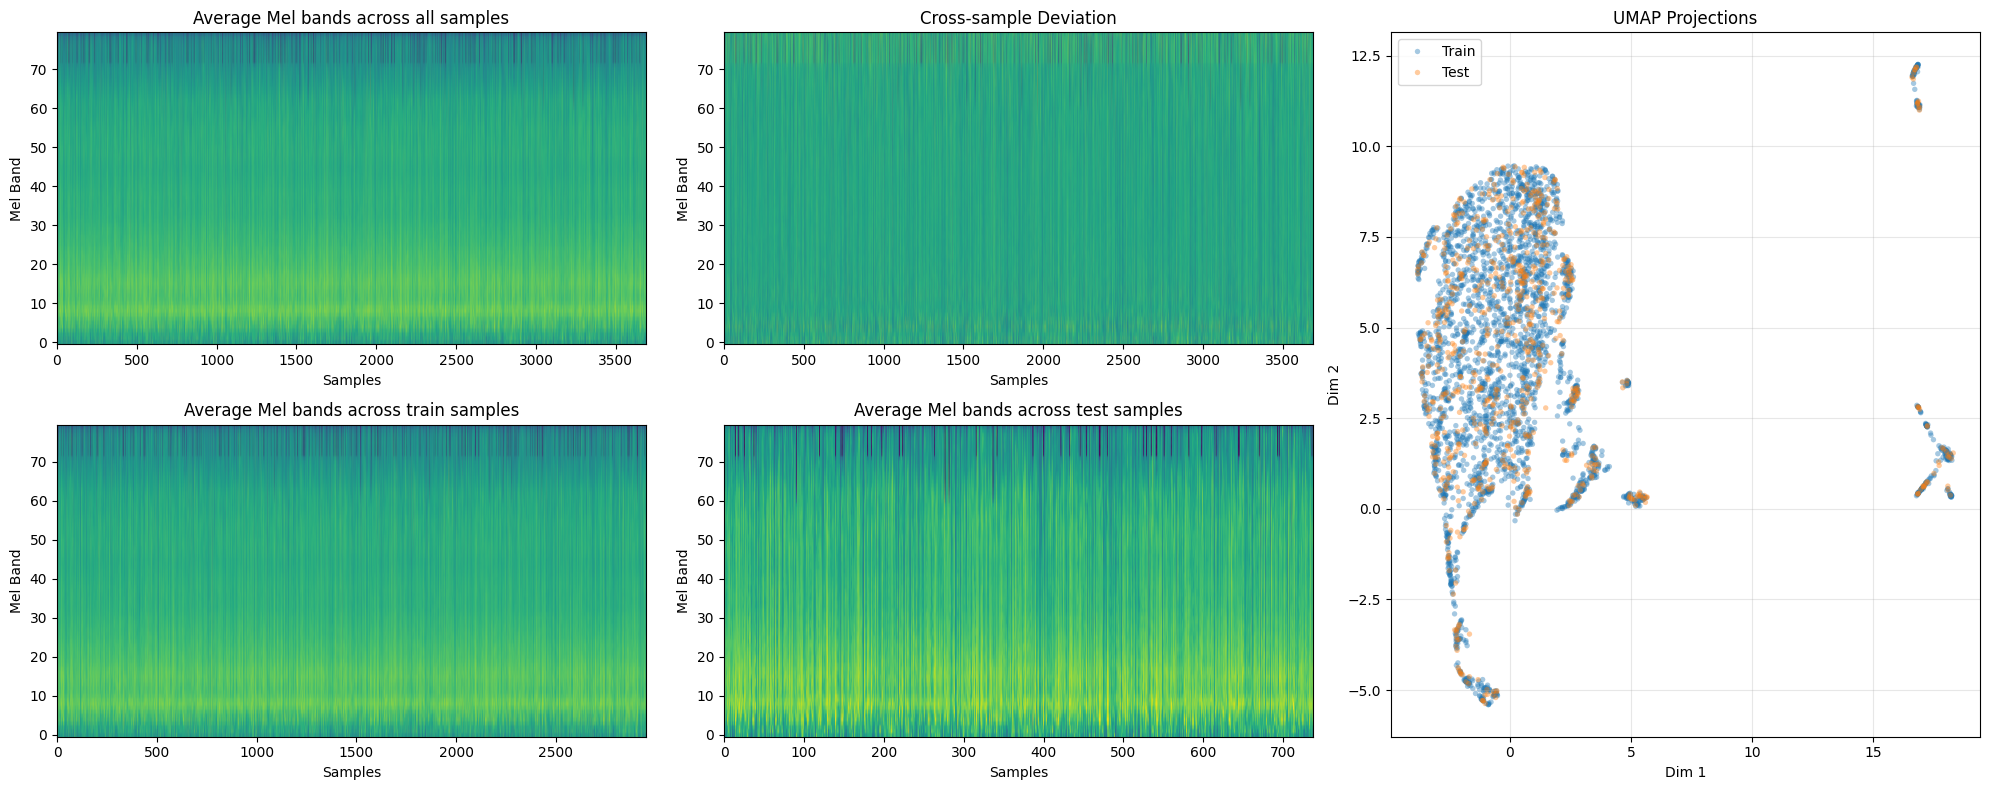

In [86]:
mel_mat = np.concat([
    spectral_feats['train']['mels'][..., 0].numpy().T,
    spectral_feats['test']['mels'][..., 0].numpy().T
], axis=-1)
mel_mu = mel_mat.mean(axis=-1, keepdims=True)

labels = np.full(mel_mat.shape[1], 'Train')
labels[-spectral_feats['test']['mels'].shape[0]:] = 'Test'


fig = plt.figure(figsize=(20, 8))
axes = fig.subplot_mosaic([
    ["all_mean", "residual", "reduced"],
    ["train", "test", "reduced"],
])

plot_spectral_stats(mel_mat, "Average Mel bands across all samples", axes["all_mean"])
plot_spectral_stats(mel_mat - mel_mu, "Cross-sample Deviation", axes['residual'])
plot_spectral_stats(
    mel_mat[..., labels == 'Train'],
    "Average Mel bands across train samples",
    axes['train']
)
plot_spectral_stats(
    mel_mat[..., labels == 'Test'],
    "Average Mel bands across test samples",
    axes['test']
)
_, mel_reduced, (scaler, reducer) = plot_reduced_dims(
    mel_mat.T,
    labels,
    axes['reduced'],
    return_reducer=True,
    umap_kwargs={
        "n_neighbors": 40,
        "min_dist": .2
    }
)

fig.tight_layout()
plt.show()

/home/cactr/Projects/denoise-vdt/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


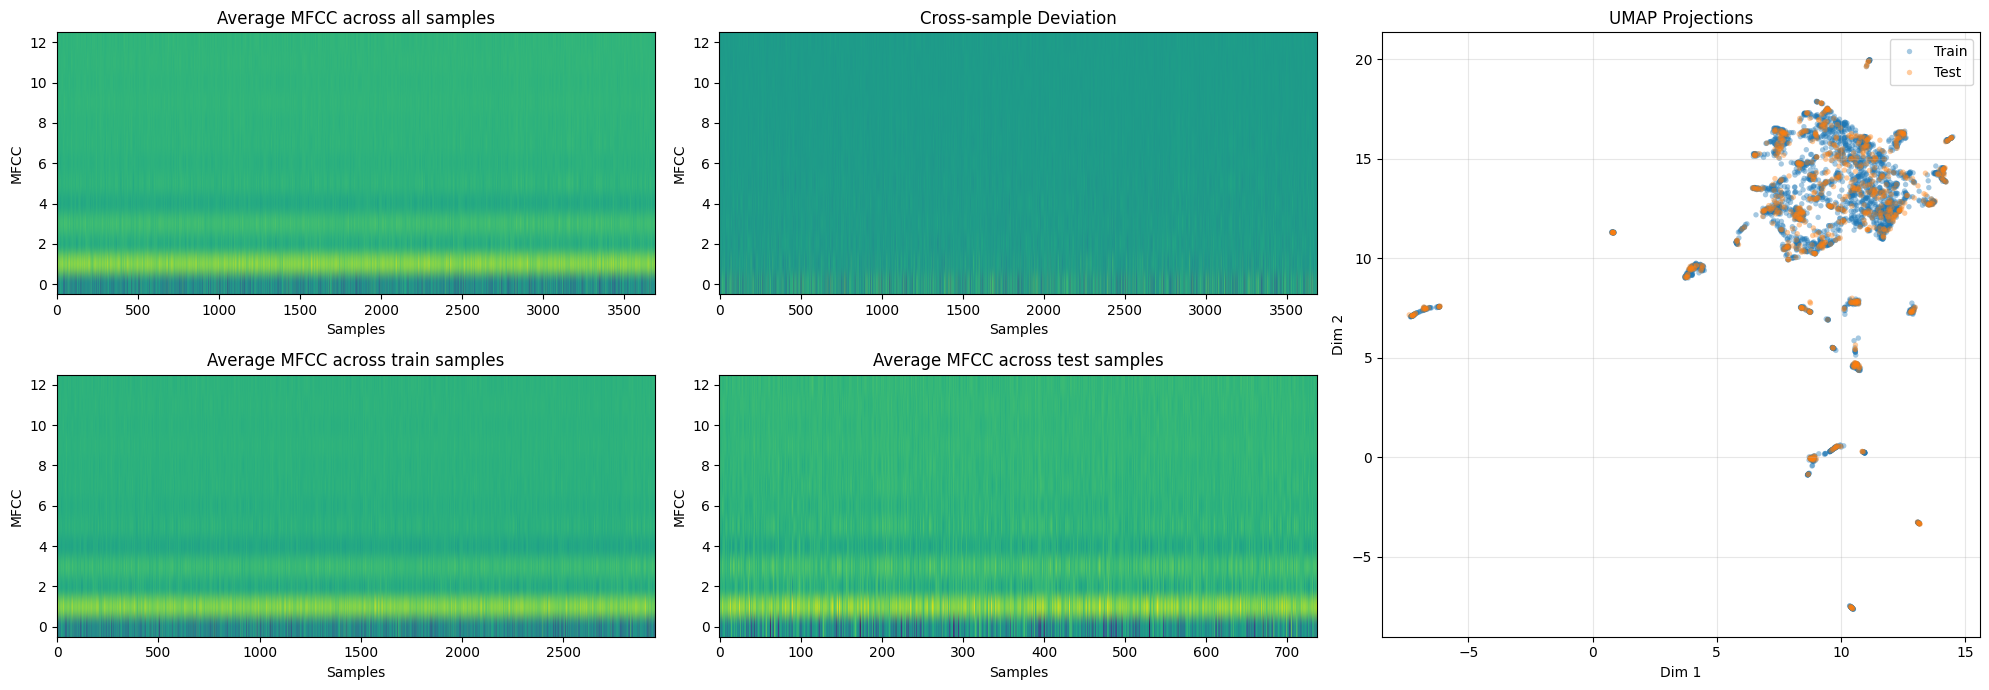

In [96]:
mfcc_mat = np.concat([
    spectral_feats['train']['mfcc'].numpy().T,
    spectral_feats['test']['mfcc'].numpy().T
], axis=-1)
mfcc_mu = mfcc_mat.mean(axis=-1, keepdims=True)

labels = np.full(mfcc_mat.shape[1], 'Train')
labels[-spectral_feats['test']['mfcc'].shape[0]:] = 'Test'


fig = plt.figure(figsize=(20, 7))
axes = fig.subplot_mosaic([
    ["all_mean", "residual", "reduced"],
    ["train", "test", "reduced"],
])

plot_spectral_stats(mfcc_mat, "Average MFCC across all samples", axes["all_mean"], ylabel="MFCC")
plot_spectral_stats(mfcc_mat - mfcc_mu, "Cross-sample Deviation", axes['residual'], ylabel="MFCC")
plot_spectral_stats(
    mfcc_mat[..., labels == 'Train'],
    "Average MFCC across train samples",
    axes['train'],
    ylabel="MFCC"
)
plot_spectral_stats(
    mfcc_mat[..., labels == 'Test'],
    "Average MFCC across test samples",
    axes['test'],
    ylabel="MFCC"
)
_, mfcc_reduced, (scaler, reducer) = plot_reduced_dims(
    mfcc_mat.T,
    labels,
    axes['reduced'],
    return_reducer=True,
    umap_kwargs={"n_neighbors": 40, "min_dist": .1}
)

fig.tight_layout()
plt.show()

In [164]:
# neighbor_0 = (mel_reduced[:, 0] >= 15) & (mel_reduced[:, 1] >= 10)
# neighbor_1 = (mel_reduced[:, 0] >= 15) & (0 <= mel_reduced[:, 1]) & (mel_reduced[:, 1] <= 5)
# neighbor_2 = (mel_reduced[:, 0] <= 15) & (0 <= mel_reduced[:, 1]) & (mel_reduced[:, 1] <= 10)
# neighbor_3 = (mel_reduced[:, 0] <= 15) & (mel_reduced[:, 1] < 0)

neighbor_0 = (mfcc_reduced[:, 0] <= -5)
neighbor_1 = (mfcc_reduced[:, 1] <= -5)
# neighbor_2 = (mfcc_reduced[:, 0] >= 5) & (mfcc_reduced[:, 0] <= 10) & (-2 <= mfcc_reduced[:, 1]) & (mfcc_reduced[:, 1] <= 2)
neighbor_2 = (mfcc_reduced[:, 0] >= 0) & (mfcc_reduced[:, 0] <= 5) & (5 <= mfcc_reduced[:, 1]) & (mfcc_reduced[:, 1] <= 10)
neighbor_3 = (mfcc_reduced[:, 0] >= 5) &  (mfcc_reduced[:, 1] >= 10)

In [205]:
n0_sam = np.where(neighbor_0)[0]
n1_sam = np.where(neighbor_1)[0]
n2_sam = np.where(neighbor_2)[0]
n3_sam = np.where(neighbor_3)[0]

idx = 5
show_audios([[
    (datasets['train']['speech_dataset']['audio'][n0_sam[idx]], 16000),
    (datasets['train']['speech_dataset']['audio'][n1_sam[idx]], 16000),
    (datasets['train']['speech_dataset']['audio'][n2_sam[idx]], 16000),
    (datasets['train']['speech_dataset']['audio'][n3_sam[idx]], 16000),
]])

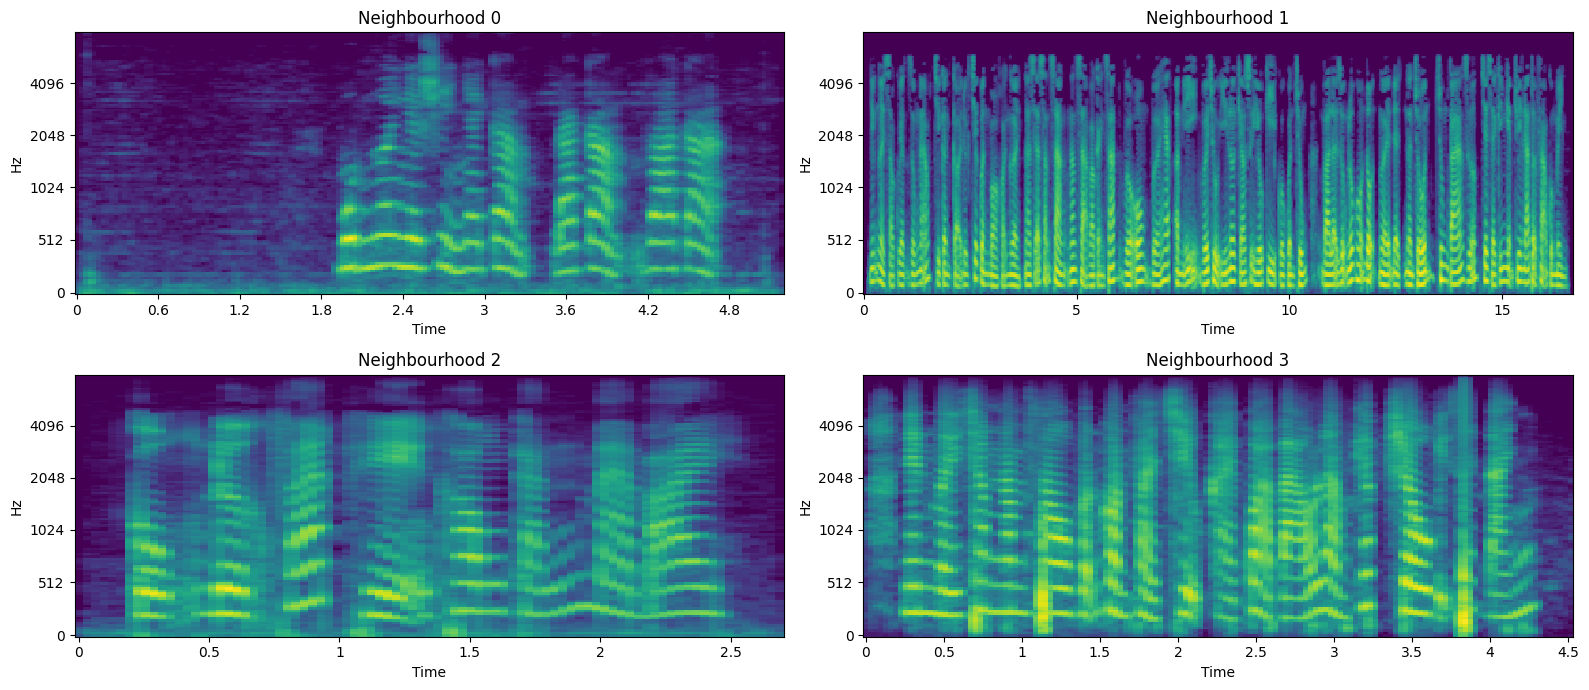

In [206]:
fig = plt.figure(figsize=(16, 7))
axes = fig.subplots(2, 2)

for i, idx in enumerate([n0_sam, n1_sam, n2_sam, n3_sam]):
    draw_spec(
        datasets['train']['speech_dataset']['audio'][idx[5]].numpy(), 16000,
        name=f"Neighbourhood {i}",
        ax=axes[i // 2, i % 2]
    )

fig.tight_layout()
plt.show()